## Imports

In [1]:
import os
import sys
import ast
import stumpy
from tabulate import tabulate
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.tools import (
    compute_lagged_correlations,
    find_dominant_lagged_pairs,
    print_dominant_pairs,
    plot_pearson_heatmap,
    report_correlation_distribution,
    classify_anomalies_multi,
    summarize,
    collect_seg_stats_multi,
    plot_threshold_sensitivity,
    compute_univariate_intensity,
    plot_univariate_intensity_distribution,
    find_contiguous_segments,
    preceding_normal_context
)

## Loading

In [2]:
path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")
print("Path to dataset files:", path)

labels_df = pd.read_csv(path + '/labeled_anomalies.csv')

smap_files = labels_df[labels_df['spacecraft'] == 'SMAP']['chan_id'].tolist()
print(f"SMAP files ({len(smap_files)}): {smap_files}")

train_dir = path + "/data/data/train"
test_dir = path + "/data/data/test"

smap_train = {ch: np.load(f"{train_dir}/{ch}.npy") for ch in smap_files}
smap_test = {ch: np.load(f"{test_dir}/{ch}.npy") for ch in smap_files}

Path to dataset files: /Users/marcp/.cache/kagglehub/datasets/patrickfleith/nasa-anomaly-detection-dataset-smap-msl/versions/1
SMAP files (55): ['P-1', 'S-1', 'E-1', 'E-2', 'E-3', 'E-4', 'E-5', 'E-6', 'E-7', 'E-8', 'E-9', 'E-10', 'E-11', 'E-12', 'E-13', 'A-1', 'D-1', 'P-2', 'P-3', 'D-2', 'D-3', 'D-4', 'A-2', 'A-3', 'A-4', 'G-1', 'G-2', 'D-5', 'D-6', 'D-7', 'F-1', 'P-4', 'G-3', 'T-1', 'T-2', 'D-8', 'D-9', 'F-2', 'G-4', 'T-3', 'D-11', 'D-12', 'B-1', 'G-6', 'G-7', 'P-7', 'R-1', 'A-5', 'A-6', 'A-7', 'D-13', 'P-2', 'A-8', 'A-9', 'F-3']


In [3]:
for ch in list(smap_train.keys())[:3]:
    print(f"{ch}: train {smap_train[ch].shape}, test {smap_test[ch].shape}")
print("...")

smap_train_dfs = [
    pd.DataFrame(data, columns=[f"{ch}_dim{d}" for d in range(data.shape[1])])
    for ch, data in smap_train.items()
]

smap_test_dfs = [
    pd.DataFrame(data, columns=[f"{ch}_dim{d}" for d in range(data.shape[1])])
    for ch, data in smap_test.items()
]

for i, df in enumerate(smap_train_dfs[:3]):
    print(f"DataFrame {i}: shape {df.shape}, columns {df.columns.tolist()[:5]}...")
print("...")


P-1: train (2872, 25), test (8505, 25)
S-1: train (2818, 25), test (7331, 25)
E-1: train (2880, 25), test (8516, 25)
...
DataFrame 0: shape (2872, 25), columns ['P-1_dim0', 'P-1_dim1', 'P-1_dim2', 'P-1_dim3', 'P-1_dim4']...
DataFrame 1: shape (2818, 25), columns ['S-1_dim0', 'S-1_dim1', 'S-1_dim2', 'S-1_dim3', 'S-1_dim4']...
DataFrame 2: shape (2880, 25), columns ['E-1_dim0', 'E-1_dim1', 'E-1_dim2', 'E-1_dim3', 'E-1_dim4']...
...


## Basic info

In [4]:
print(len(smap_train_dfs))
print(len(smap_test_dfs))
print(sum(df.shape[0] for df in smap_train_dfs))

print("SMAP stats per file")
for ch, data in smap_train.items():
    print(f"{ch}: shape={data.shape}, min={data.min():.4f}, max={data.max():.4f}, mean={data.mean():.4f}, std={data.std():.4f}")

print("Global stats")
all_mins = [data.min() for data in smap_train.values()]
all_maxs = [data.max() for data in smap_train.values()]
all_means = [data.mean() for data in smap_train.values()]
all_stds = [data.std() for data in smap_train.values()]

print(f"Min global: {min(all_mins):.4f}")
print(f"Max global: {max(all_maxs):.4f}")
print(f"Mean range: [{min(all_means):.4f}, {max(all_means):.4f}]")
print(f"Std range: [{min(all_stds):.4f}, {max(all_stds):.4f}]")

54
54
138004
SMAP stats per file
P-1: shape=(2872, 25), min=-1.0000, max=1.0000, mean=0.0029, std=0.1836
S-1: shape=(2818, 25), min=-0.4000, max=1.0000, mean=0.0170, std=0.1733
E-1: shape=(2880, 25), min=-1.0000, max=1.0000, mean=-0.0019, std=0.2482
E-2: shape=(2880, 25), min=-1.0000, max=1.0000, mean=0.0048, std=0.1997
E-3: shape=(2880, 25), min=-1.0000, max=1.0000, mean=0.0266, std=0.1679
E-4: shape=(2880, 25), min=-1.0000, max=1.0000, mean=0.0052, std=0.1927
E-5: shape=(2880, 25), min=-1.0000, max=1.0000, mean=-0.0024, std=0.2471
E-6: shape=(2880, 25), min=0.0000, max=1.0000, mean=0.0618, std=0.2401
E-7: shape=(2769, 25), min=-1.0000, max=1.0000, mean=-0.0170, std=0.2433
E-8: shape=(2880, 25), min=-1.0000, max=1.0000, mean=0.0110, std=0.1855
E-9: shape=(2880, 25), min=-1.0000, max=1.0000, mean=0.0171, std=0.1799
E-10: shape=(2880, 25), min=-1.0000, max=1.0000, mean=-0.0020, std=0.2479
E-11: shape=(2880, 25), min=-1.0000, max=1.0000, mean=-0.0018, std=0.2483
E-12: shape=(2880, 25), m

## Data exploration

In [5]:
smap_train_dfs[2].describe()

a = 0
for i, df in enumerate(smap_train_dfs):
    if df.isnull().values.any():
        print(f"DataFrame {i} has missing values.")
        a += 1

if a == 0:
    print("No missing values found in any DataFrame.")

No missing values found in any DataFrame.


In [6]:
all_train_entries = sum(df.shape[0] for df in smap_train_dfs)
print(f"Total number of entries in SMAP train data: {all_train_entries}")
all_test_entries = sum(data.shape[0] for data in smap_test.values())
print(f"Total number of entries in SMAP test data: {all_test_entries}")

Total number of entries in SMAP train data: 138004
Total number of entries in SMAP test data: 435826


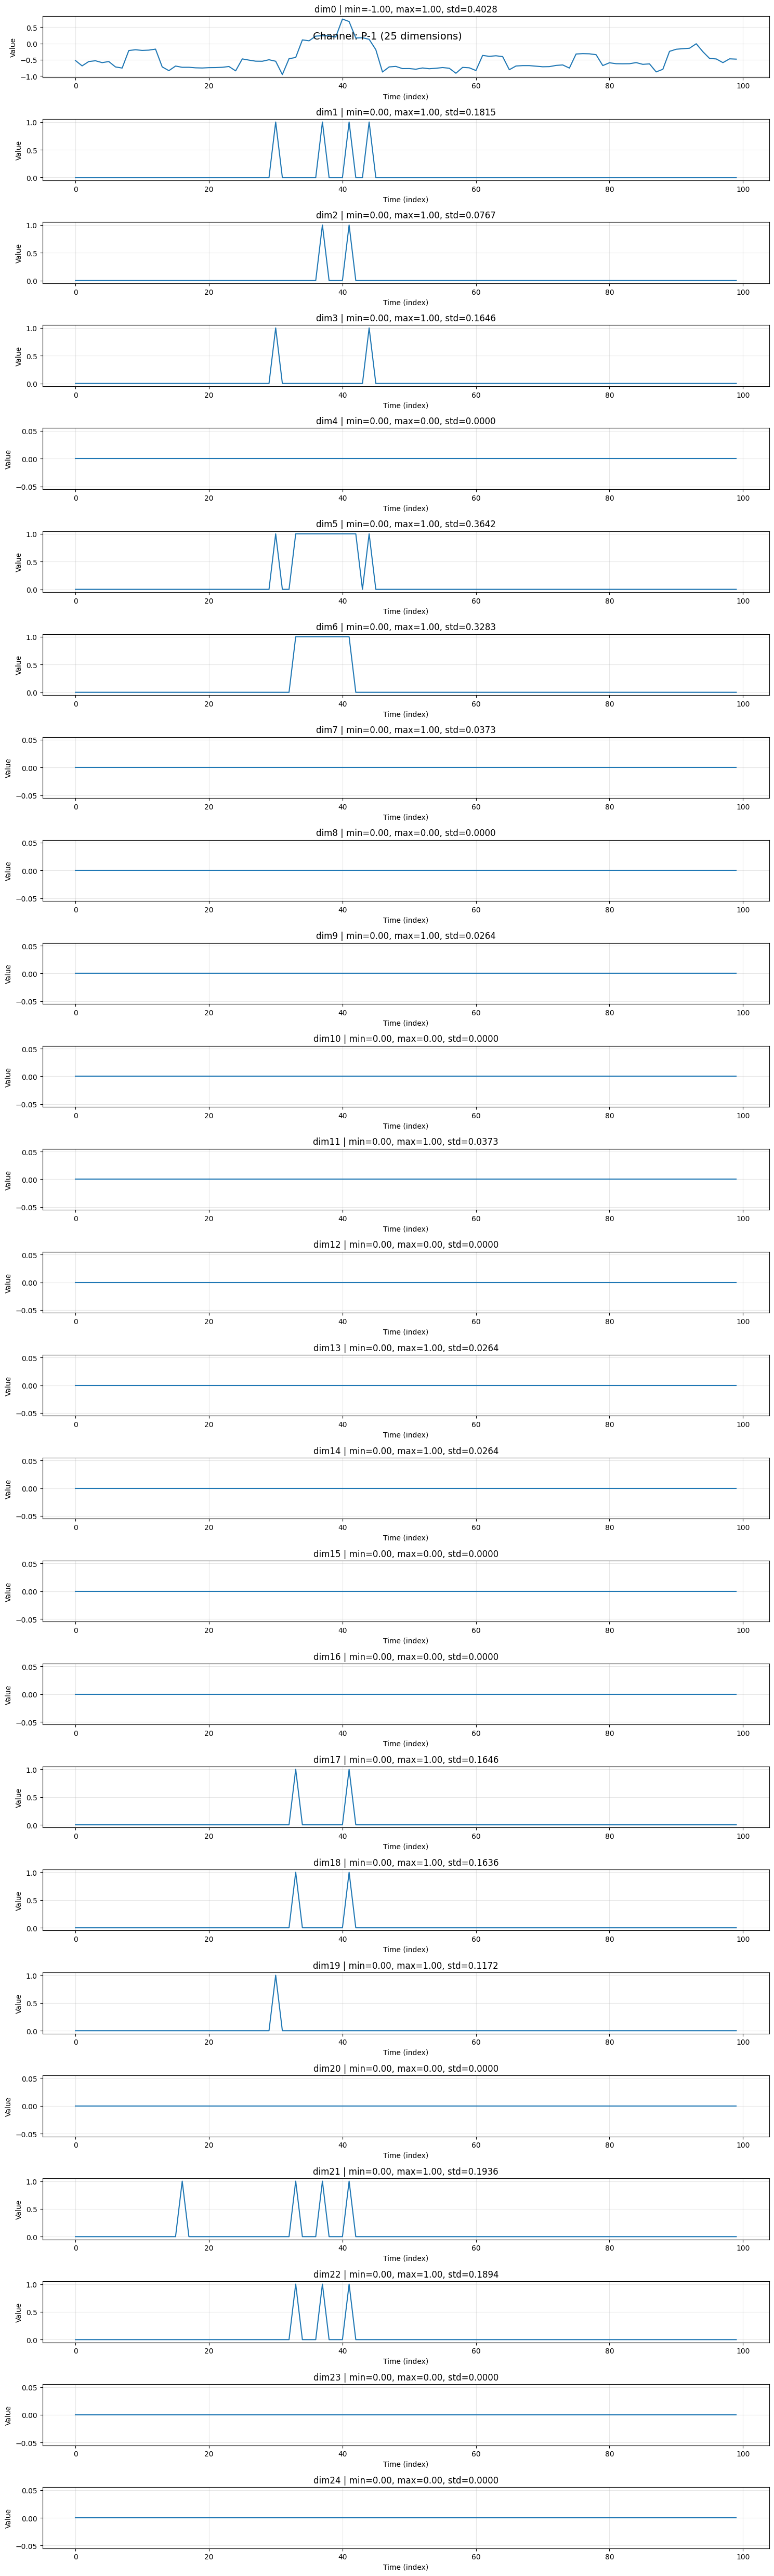

In [7]:
num_channels = len(smap_train)
num_points = 100

for ch, data in smap_train.items():
    num_dims = data.shape[1]
    fig, axes = plt.subplots(num_dims, 1, figsize=(15, num_dims * 2), squeeze=False)
    fig.suptitle(f"Channel: {ch} ({num_dims} dimensions)", fontsize=14)

    for d in range(num_dims):
        ax = axes[d, 0]
        ax.plot(data[:num_points, d])
        ax.set_title(f"dim{d} | min={data[:, d].min():.2f}, max={data[:, d].max():.2f}, std={data[:, d].std():.4f}")
        ax.set_xlabel('Time (index)')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    break  # to avoid plotting all files

## Correlation analysis on normal data

In [8]:
labels_df = pd.read_csv(path + '/labeled_anomalies.csv')
 
smap_train = {ch: np.load(f"{train_dir}/{ch}.npy") for ch in smap_files}
smap_test = {ch: np.load(f"{test_dir}/{ch}.npy") for ch in smap_files}

In [9]:
train_data_list = [smap_train[ch].astype(np.float64) for ch in smap_files]
test_data_list = [smap_test[ch].astype(np.float64) for ch in smap_files]
 
test_labels_list = []
for ch in smap_files:
    row = labels_df[labels_df['chan_id'] == ch].iloc[0]
    seqs = ast.literal_eval(row['anomaly_sequences'])
    test_len = smap_test[ch].shape[0]
    lab = np.zeros(test_len, dtype=int)
    for start, end in seqs:
        lab[start:end+1] = 1
    test_labels_list.append(lab)
 
print(f"Channels: {len(train_data_list)}")
print(f"Total train entries: {sum(len(a) for a in train_data_list)}")
print(f"Total test entries: {sum(len(a) for a in test_data_list)}")
print(f"Total anomalous test entries: {sum(int(l.sum()) for l in test_labels_list)}")

Channels: 55
Total train entries: 140825
Total test entries: 444035
Total anomalous test entries: 57148


In [10]:
all_clean = all(np.isnan(a).sum() == 0 for a in train_data_list)
print("NaN in train_data_list:", not all_clean)

NaN in train_data_list: False


In [11]:
max_lag = 192
L_min = 2 * max_lag
 
segments = [arr for arr in train_data_list if len(arr) >= L_min]
print(f"Kept channels (L >= {L_min}): {len(segments)}/{len(train_data_list)}")
 
C = segments[0].shape[1]
features = [str(i) for i in range(C)]
seg_lengths = [len(s) for s in segments]
print(f"min={min(seg_lengths)}, max={max(seg_lengths)}, total={sum(seg_lengths)}")

Kept channels (L >= 384): 54/55
min=682, max=2881, total=140513


In [12]:
lagged_corrs = compute_lagged_correlations(segments, max_lag=max_lag, progress=True)

Segments (Spearman): 100%|██████████| 54/54 [00:02<00:00, 18.99it/s]


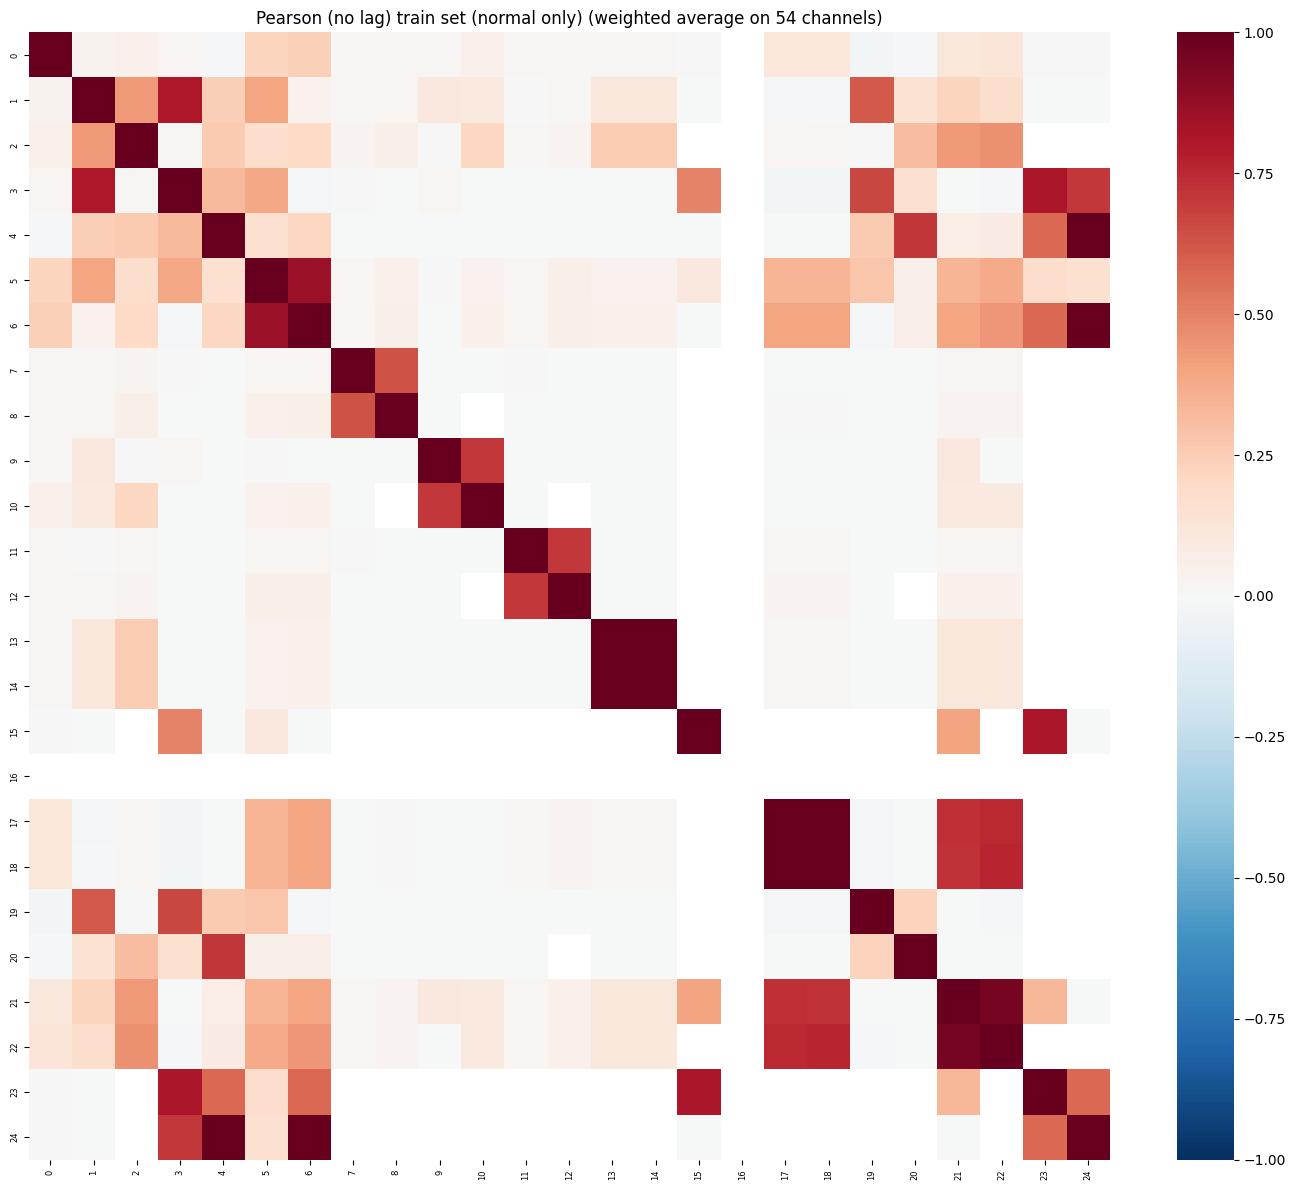

In [13]:
pearson_matrix_mean = lagged_corrs['pearson'][:, :, max_lag]
plot_pearson_heatmap(
    pearson_matrix_mean, features,
    title=f"Pearson (no lag) train set (normal only) (weighted average on {len(segments)} channels)",
)

In [14]:
print("|r| distribution (without the diagonal):")
report_correlation_distribution(pearson_matrix_mean)

|r| distribution (without the diagonal):
Total pairs: 231
  Pairs with |r| > 0.3: 41/231 (17.7%)
  Pairs with |r| > 0.5: 23/231 (10.0%)
  Pairs with |r| > 0.7: 17/231 (7.4%)


In [15]:
pairs_info = find_dominant_lagged_pairs(lagged_corrs, max_lag=max_lag, threshold=0.5)
print("Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):")
print_dominant_pairs(pairs_info)

Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):
Total pairs: 171
4 - 12: r(0)=-0.000  r(+127)=+1.000  [spearman]
1 - 24: r(0)=-0.002  r(+6)=+1.000  [pearson]
1 - 15: r(0)=-0.002  r(-21)=+0.706  [pearson]
4 - 15: r(0)=-0.002  r(-27)=+0.706  [pearson]
6 - 15: r(0)=-0.002  r(-27)=+0.706  [pearson]
15 - 24: r(0)=-0.002  r(+27)=+0.706  [pearson]
3 - 24: r(0)=+0.706  r(+18)=+0.706  [pearson]
1 - 23: r(0)=-0.003  r(-21)=+0.576  [pearson]
4 - 23: r(0)=+0.576  r(-27)=+0.576  [pearson]
6 - 23: r(0)=+0.576  r(-27)=+0.576  [pearson]
23 - 24: r(0)=+0.576  r(+27)=+0.576  [pearson]
21 - 24: r(0)=-0.003  r(+6)=+0.576  [pearson]
8 - 12: r(0)=-0.001  r(+4)=+0.533  [pearson]
7 - 11: r(0)=+0.004  r(-1)=+0.473  [spearman]
8 - 20: r(0)=-0.001  r(+39)=+0.425  [spearman]
15 - 21: r(0)=+0.406  r(+9)=+0.406  [pearson]
17 - 19: r(0)=-0.018  r(-3)=+0.366  [spearman]
18 - 19: r(0)=-0.018  r(-3)=+0.364  [spearman]
7 - 12: r(0)=-0.001  r(-1)=+0.350  [spearman]
4 - 8: r(0)=-0.001  r(+5)=+0.

## Anomaly analysis

In [16]:
n_train = sum(len(a) for a in train_data_list)
n_test = sum(len(a) for a in test_data_list)
n_anom = sum(int(l.sum()) for l in test_labels_list)
dim = train_data_list[0].shape[1]

print(f"Dimension: {dim}")
print(f"Train Size: {n_train}")
print(f"Test (labeled): {n_test}")
print(f"Anomaly Ratio (%): {100.0 * n_anom / n_test:.2f}")

Dimension: 25
Train Size: 140825
Test (labeled): 444035
Anomaly Ratio (%): 12.87


In [17]:
df_long, df_short = classify_anomalies_multi(
    test_arrays=test_data_list,
    label_arrays=test_labels_list,
    names=smap_files,
    train_arrays=train_data_list,
    pairs_info=pairs_info,
    id_col='channel',
)
summarize(df_long, df_short)

Counts per method (long segments):
+----------------------+-----------+------------+--------+
| label                |   pearson |   spearman |   dcor |
|----------------------+-----------+------------+--------|
| UNIVARIATE           |        15 |         15 |     16 |
| BOTH                 |        41 |         41 |     40 |
| CROSS-CHANNEL        |         0 |          0 |      0 |
| UNDETECTED           |        13 |         13 |     13 |
| INSUFFICIENT_CONTEXT |         0 |          0 |      0 |
+----------------------+-----------+------------+--------+

Counts (short segments, < min_len points):
+----------------------+---------+
| label                |   count |
|----------------------+---------|
| UNIVARIATE           |       0 |
| UNDETECTED           |       0 |
| INSUFFICIENT_CONTEXT |       0 |
+----------------------+---------+


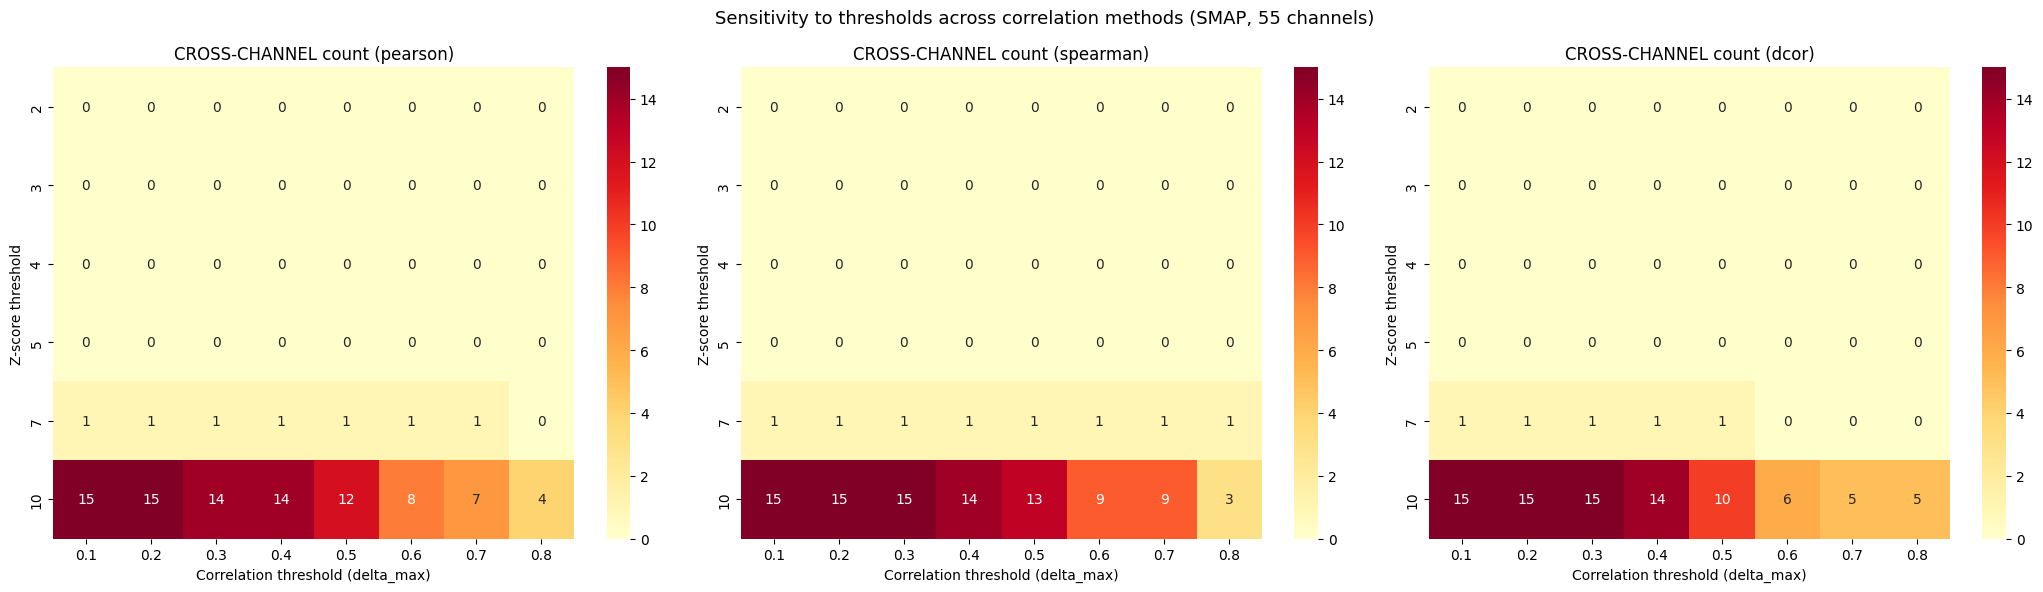

{'pearson': array([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  1,  1,  1,  1,  1,  1,  0],
        [15, 15, 14, 14, 12,  8,  7,  4]]),
 'spearman': array([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  1,  1,  1,  1,  1,  1,  1],
        [15, 15, 15, 14, 13,  9,  9,  3]]),
 'dcor': array([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 1,  1,  1,  1,  1,  0,  0,  0],
        [15, 15, 15, 14, 10,  6,  5,  5]])}

In [18]:
seg_stats = collect_seg_stats_multi(
    test_arrays=test_data_list,
    label_arrays=test_labels_list,
    train_arrays=train_data_list,
    pairs_info=pairs_info,
)
plot_threshold_sensitivity(
    seg_stats,
    title=f"Sensitivity to thresholds across correlation methods (SMAP, {len(smap_files)} channels)",
)

In [19]:
intensity_df, summary = compute_univariate_intensity(
    test_arrays=test_data_list, label_arrays=test_labels_list,
    names=smap_files, train_arrays=train_data_list,
)
print(tabulate(summary, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))


+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       69.000 |            0.212 |              0.071 |           0.000 |
+--------------+------------------+--------------------+-----------------+


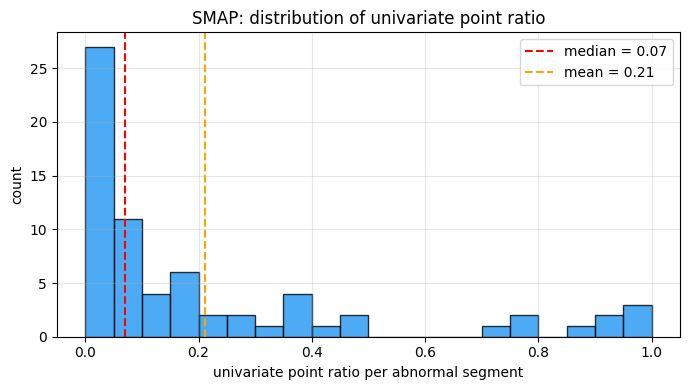

In [20]:
plot_univariate_intensity_distribution(intensity_df, 'SMAP')

Due to the categorical and discrete nature of MSL and SMAP, it is harder to interprete the graph.

BOTH segments (union over pearson/spearman/dcor): 41
Channels containing >=1 BOTH segment: 32 / 55
Anomalous points retained: 33606 / 57148 (58.8%)
+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|       41.000 |            0.230 |              0.125 |           0.008 |
+--------------+------------------+--------------------+-----------------+


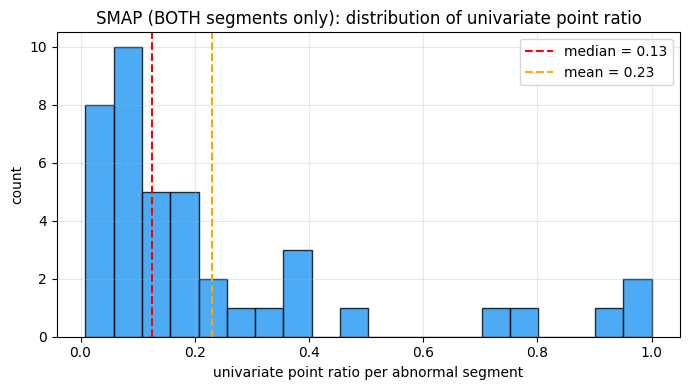

In [21]:
both_mask = (
    (df_long['lab_pearson'] == 'BOTH') |
    (df_long['lab_spearman'] == 'BOTH') |
    (df_long['lab_dcor'] == 'BOTH')
)
df_both = df_long.loc[both_mask, ['channel', 'start', 'end']]

ev_both_list = []
for k, ch in enumerate(smap_files):
    ev_both = np.zeros_like(test_labels_list[k])
    for _, r in df_both[df_both['channel'] == ch].iterrows():
        ev_both[int(r['start']):int(r['end'])] = 1
    ev_both_list.append(ev_both)

n_seg_both = len(df_both)
n_pts_both = int(sum(int(e.sum()) for e in ev_both_list))
n_pts_total = int(sum(int(l.sum()) for l in test_labels_list))
n_channels_both = int((df_both['channel'].nunique()))

print(f"BOTH segments (union over pearson/spearman/dcor): {n_seg_both}")
print(f"Channels containing >=1 BOTH segment: {n_channels_both} / {len(smap_files)}")
print(f"Anomalous points retained: {n_pts_both} / {n_pts_total} ({100.0 * n_pts_both / max(n_pts_total, 1):.1f}%)")

intensity_df_both, summary_both = compute_univariate_intensity(
    test_arrays=test_data_list,
    label_arrays=ev_both_list,
    names=smap_files,
    train_arrays=train_data_list,
)
print(tabulate(summary_both, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

plot_univariate_intensity_distribution(intensity_df_both, 'SMAP (BOTH segments only)')

In [22]:
print("Min segment length:", df_long['end'] - df_long['start'] + 1)

Min segment length: 0      202
1      242
2      310
3      449
4       32
      ... 
64     162
65    1227
66    3807
67    3866
68      42
Length: 69, dtype: int64


In [23]:
WINDOW_SIZE = 30  # detection rate stable at 85% for m in {15, 20, 30} => chosen to cover all segments of length >= 31
MP_Z_THR = 3  # based on the z-score default


def mp_univariate_test(anom, ctx, m, z_thr):
    if anom.shape[0] < m or ctx.shape[0] < 2 * m:
        return False, np.nan, -1
    best_z, best_ch = -np.inf, -1
    for c in range(anom.shape[1]):
        a, b = anom[:, c].astype(np.float64), ctx[:, c].astype(np.float64)
        if a.std() < 1e-3 or b.std() < 1e-3:
            continue
        try:
            mp_ab = stumpy.stump(a, m, b, ignore_trivial=False, normalize=False)[:, 0].astype(np.float64)
            mp_bb = stumpy.stump(b, m, normalize=False)[:, 0].astype(np.float64)
        except Exception:
            continue
        mu, sigma = np.nanmean(mp_bb), np.nanstd(mp_bb)
        if sigma < 1e-3 or not np.isfinite(mu):
            continue
        z = (np.nanmax(mp_ab) - mu) / sigma
        if z > best_z:
            best_z, best_ch = z, c
    return (np.isfinite(best_z) and best_z > z_thr,
            best_z if np.isfinite(best_z) else np.nan, best_ch)


rows = []
for k, ch in enumerate(smap_files):
    seg_ch = intensity_df_both[intensity_df_both['channel'] == ch]
    if len(seg_ch) == 0:
        continue
    X = StandardScaler().fit(train_data_list[k]).transform(test_data_list[k])
    ev = test_labels_list[k].astype(int)
    contiguous = find_contiguous_segments(ev)
    for _, r in seg_ch.iterrows():
        seg_len = int(r['len'])
        match = next((s for s in contiguous if (s[1] - s[0]) == seg_len), None)
        base = {'channel': ch, 'len': seg_len, 'ratio_uni_z': float(r['ratio_uni'])}
        if match is None:
            rows.append({**base, 'mp_detected': None, 'mp_max_z': np.nan, 'mp_argmax_ch': -1, 'note': 'segment_not_localized'})
            continue
        s, e = match
        anom = X[s:e]
        anom = anom[~np.isnan(anom).any(axis=1)] if np.isnan(anom).any() else anom
        ctx = preceding_normal_context(s, X, ev == 0, ctx_size=300)
        if ctx is None:
            rows.append({**base, 'mp_detected': None, 'mp_max_z': np.nan, 'mp_argmax_ch': -1, 'note': 'no_context'})
            continue
        detected, z, c_star = mp_univariate_test(anom, ctx, WINDOW_SIZE, MP_Z_THR)
        rows.append({**base, 'mp_detected': detected, 'mp_max_z': z, 'mp_argmax_ch': c_star, 'note': 'ok'})

df_mp = pd.DataFrame(rows, columns=['channel', 'len', 'ratio_uni_z', 'mp_detected', 'mp_max_z', 'mp_argmax_ch', 'note'])
print(tabulate(df_mp, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

ok = df_mp[df_mp['note'] == 'ok']
n_eval, n_det = len(ok), int((ok['mp_detected'] == True).sum())
n_skip = int((df_mp['note'] != 'ok').sum())
print(f"SMAP BOTH segments evaluated by MP: {n_eval}")
print(f"Detected by MP (z > {MP_Z_THR}): {n_det}")
print(f"Missed by MP: {n_eval - n_det}")
print(f"Skipped (no context or unmatched): {n_skip}")
if n_eval:
    print(f"Detection rate: {100.0 * n_det / n_eval:.1f}%")

/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)
/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)
/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)
/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)
/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/stumpy/core.py:354

+-----------+-------+---------------+---------------+------------+----------------+--------+
| channel   |   len |   ratio_uni_z |   mp_detected |   mp_max_z |   mp_argmax_ch | note   |
|-----------+-------+---------------+---------------+------------+----------------+--------|
| P-1       |   201 |         0.119 |         1.000 |      4.881 |             18 | ok     |
| P-1       |   241 |         0.071 |         0.000 |      2.298 |             22 | ok     |
| P-1       |   309 |         0.123 |         0.000 |      2.834 |              2 | ok     |
| S-1       |   448 |         0.011 |         1.000 |      8.363 |              0 | ok     |
| E-1       |    31 |         0.226 |         1.000 |     11.328 |              0 | ok     |
| E-1       |   477 |         0.008 |         1.000 |      8.417 |              0 | ok     |
| E-2       |  1398 |         0.125 |         1.000 |     49.451 |              0 | ok     |
| E-3       |  3213 |         0.753 |         1.000 |    195.846 |    

/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/stumpy/core.py:3548: UserWarning: A large number of values in `P` are smaller than 1e-06.
For a self-join, try setting `ignore_trivial=True`.
  warnings.warn(msg)


Plotting 6 missed segments


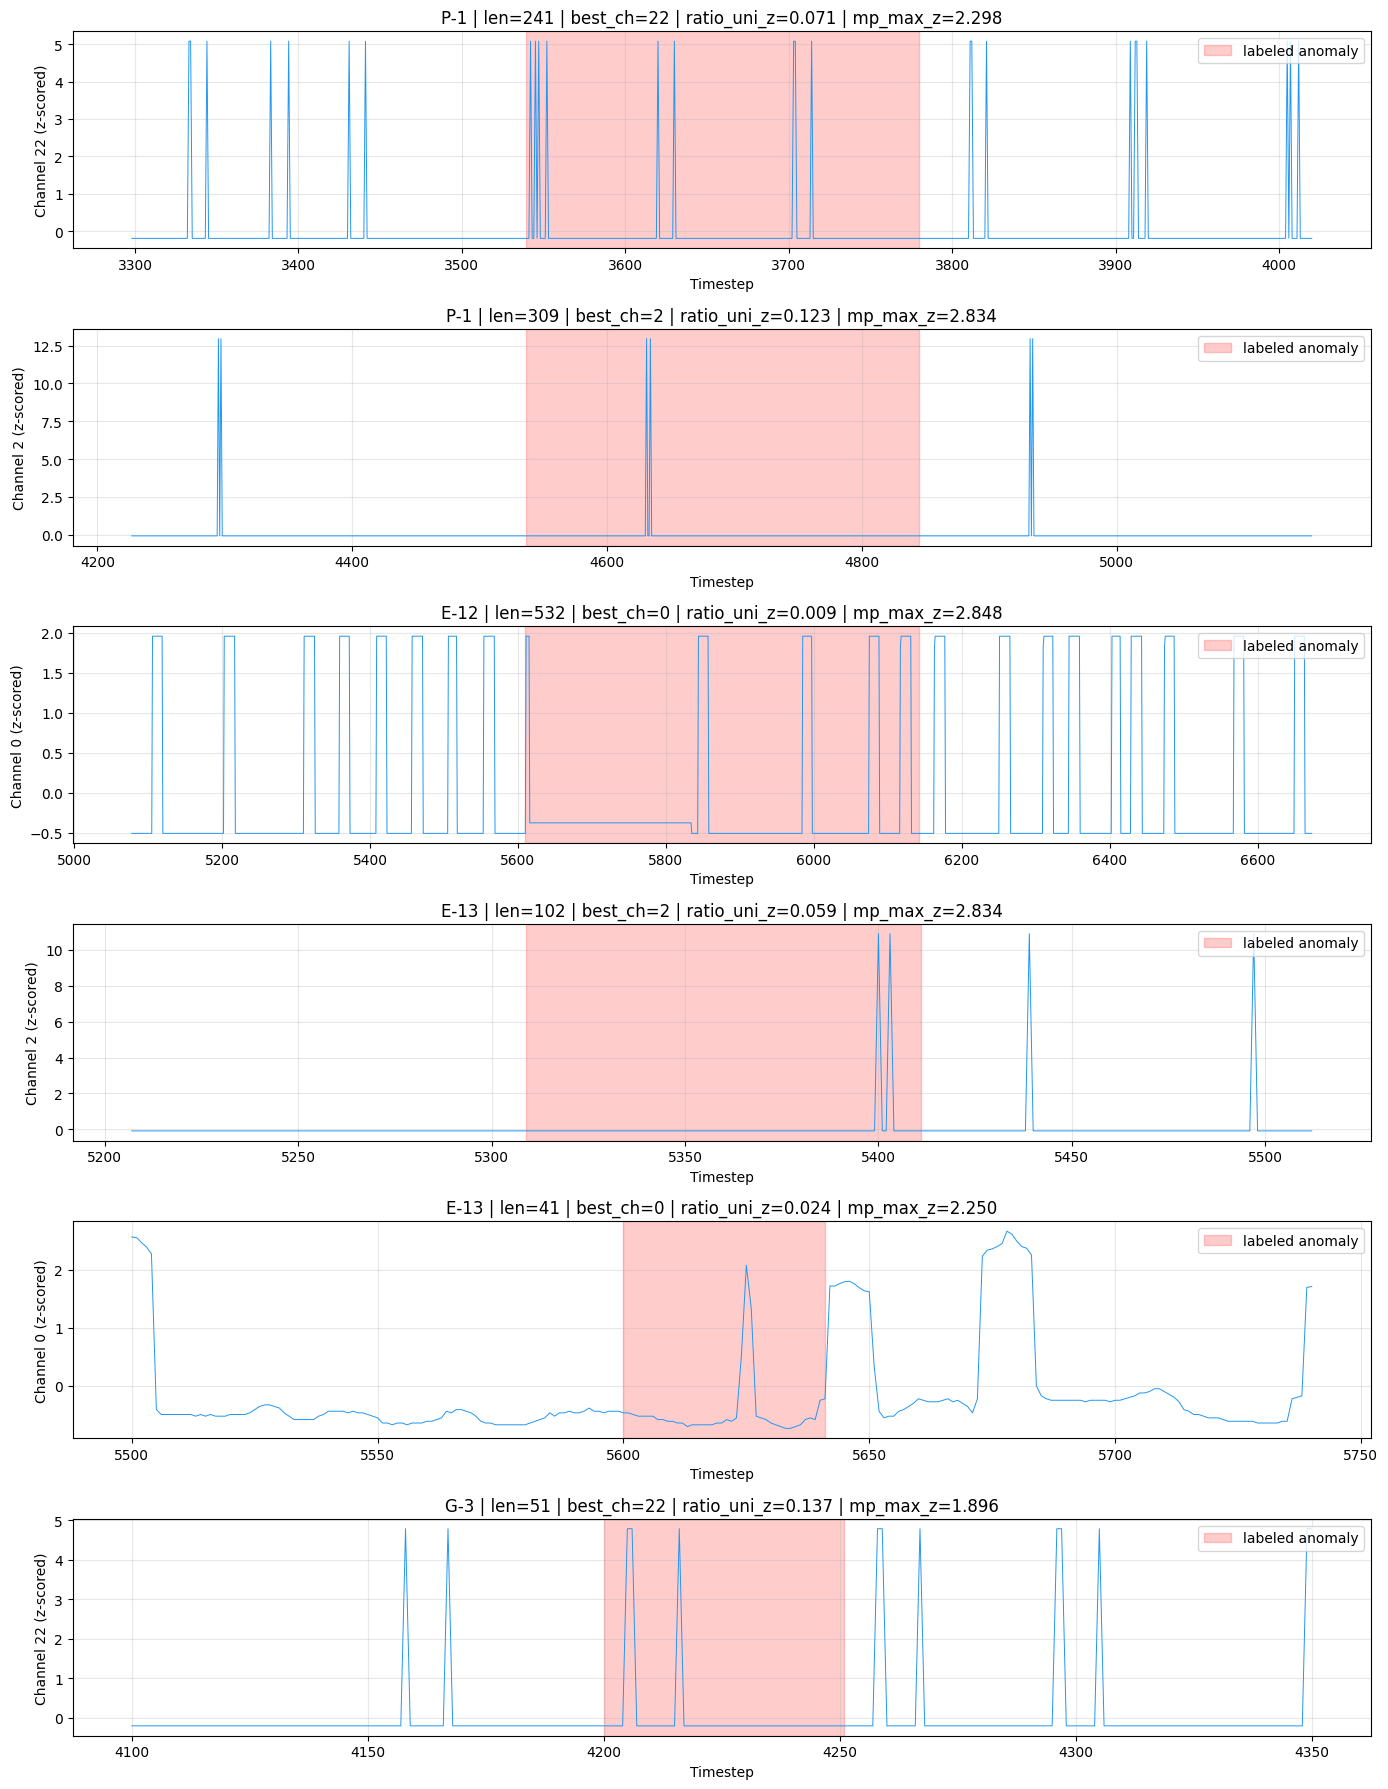

In [24]:
# Let's see which one the Matrix Profile missed (we take the most influential channel for each segment (with highest z-score)):
missed = df_mp[(df_mp['note'] == 'ok') & (df_mp['mp_detected'] == False)]
print(f"Plotting {len(missed)} missed segments")

fig, axes = plt.subplots(len(missed), 1, figsize=(14, 3 * len(missed)), squeeze=False)

for i, (_, r) in enumerate(missed.iterrows()):
    ch, seg_len = r['channel'], int(r['len'])
    k = smap_files.index(ch)
    X = StandardScaler().fit(train_data_list[k]).transform(test_data_list[k])
    ev = test_labels_list[k].astype(int)
    s, e = next(seg for seg in find_contiguous_segments(ev) if (seg[1] - seg[0]) == seg_len)
    margin = max(100, seg_len)
    view_s, view_e = max(0, s - margin), min(len(X), e + margin)
    c = int(r['mp_argmax_ch'])
    ax = axes[i, 0]
    ax.plot(range(view_s, view_e), X[view_s:view_e, c], linewidth=0.7, color='#2196F3')
    ax.axvspan(s, e, alpha=0.2, color='red', label='labeled anomaly')
    ax.set_title(f"{ch} | len={seg_len} | best_ch={c} | ratio_uni_z={r['ratio_uni_z']:.3f} | mp_max_z={r['mp_max_z']:.3f}")
    ax.set_xlabel('Timestep')
    ax.set_ylabel(f'Channel {c} (z-scored)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Probably miss labeled data.